In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import statsmodels.api as sm
from scipy import stats
import nibabel as nib
import seaborn as sns

In [2]:
age_H = pd.read_csv('../derivatives/hurst.csv')
age_H=age_H[age_H.motion<0.012]

In [3]:
age_H.iloc[:, :-5].mean().mean() + 0.08

1.099416040109157

In [4]:
age_H = pd.read_csv('../derivatives/hurst.csv')
age_H=age_H[age_H.motion<0.012]
residuals = pd.DataFrame()
for column in age_H.columns[:64]:
    y = age_H[column]
    X = sm.add_constant(age_H.motion)
    model = sm.OLS(y, X).fit()
    residuals[column] = model.resid
age_H.iloc[:, :64] = residuals
allregions = age_H.columns[:64]

In [5]:
atlas = pd.read_csv('../dataset/template/rat_brainregions.csv')
regions = pd.read_csv('../dataset/template/rat_brainatlas.csv', header=None)

In [6]:
regions.columns = ['region', 'fullname', 'category']

In [7]:
alcohol_effect = pd.read_csv('../derivatives/alcohol_motionlimited_effect.csv')
alcohol_effect['region'] = allregions

In [8]:
all_atlas = pd.DataFrame()
for i in np.arange(atlas.shape[0]):
    region = atlas.iloc[i, 1:].values
    all_region = pd.DataFrame()
    for r in region:
        if r in alcohol_effect.region.values:
            all_region = pd.concat([all_region, alcohol_effect[alcohol_effect.region==r].loc[:, ['alcohol','alcohol.2']]])
    all_atlas = pd.concat([all_atlas, pd.DataFrame(all_region.mean()).T])
all_atlas = all_atlas.reset_index(drop=True)
all_atlas['alcohol.2'] = [2 if x<0 else 1 for x in all_atlas['alcohol.2']]

In [9]:
for x in ['alcohol', 'alcohol.2']:
    img = nib.load('../dataset/template/Rat_CAMRI_400um_ATLAS.nii.gz')
    data = img.get_fdata()
    for parcel_index, new_value in enumerate(all_atlas[x].values):
        data[data == (parcel_index+1)] = 0.03-np.abs(new_value)
    new_img = nib.Nifti1Image(data, img.affine, img.header)
    nib.save(new_img, '../dataset/template/'+x+'.nii.gz')

In [10]:
alcohol_effect = pd.merge(alcohol_effect, regions, on = 'region')
alcohol_effect = alcohol_effect.loc[:, ['alcohol', 'alcohol.1', 'alcohol.2', 'category']].groupby('category').mean().reset_index()

In [11]:
mean = pd.DataFrame([allregions, age_H[age_H.run==2].iloc[:, :-5].mean().values]).T
mean.columns = ['region', 'hurst']
saline = pd.merge(mean, regions, on='region').loc[:, ['hurst', 'category']].groupby('category').mean().reset_index().hurst
mean = pd.DataFrame([allregions, age_H[age_H.run==3].iloc[:, :-5].mean().values]).T
mean.columns = ['region', 'hurst']
dose1 = pd.merge(mean, regions, on='region').loc[:, ['hurst', 'category']].groupby('category').mean().reset_index().hurst
mean = pd.DataFrame([allregions, age_H[age_H.run==4].iloc[:, :-5].mean().values]).T
mean.columns = ['region', 'hurst']
dose2 = pd.merge(mean, regions, on='region').loc[:, ['hurst', 'category']].groupby('category').mean().reset_index().hurst
mean = pd.DataFrame([allregions, age_H[age_H.run==5].iloc[:, :-5].mean().values]).T
mean.columns = ['region', 'hurst']
dose3 = pd.merge(mean, regions, on='region').loc[:, ['hurst', 'category']].groupby('category').mean().reset_index().hurst
dfall = pd.DataFrame([saline, dose1, dose2, dose3]).T
dfall.columns = ['saline', 'dose1', 'dose2', 'dose3']
dfall['category'] = pd.merge(mean, regions, on='region').loc[:, ['hurst', 'category']].groupby('category').mean().reset_index().category

In [12]:
mean = pd.DataFrame([allregions, age_H[age_H.run==2].iloc[:, :-5].sem().values]).T
mean.columns = ['region', 'hurst']
saline = pd.merge(mean, regions, on='region').loc[:, ['hurst', 'category']].groupby('category').mean().reset_index().hurst
mean = pd.DataFrame([allregions, age_H[age_H.run==3].iloc[:, :-5].sem().values]).T
mean.columns = ['region', 'hurst']
dose1 = pd.merge(mean, regions, on='region').loc[:, ['hurst', 'category']].groupby('category').mean().reset_index().hurst
mean = pd.DataFrame([allregions, age_H[age_H.run==4].iloc[:, :-5].sem().values]).T
mean.columns = ['region', 'hurst']
dose2 = pd.merge(mean, regions, on='region').loc[:, ['hurst', 'category']].groupby('category').mean().reset_index().hurst
mean = pd.DataFrame([allregions, age_H[age_H.run==5].iloc[:, :-5].sem().values]).T
mean.columns = ['region', 'hurst']
dose3 = pd.merge(mean, regions, on='region').loc[:, ['hurst', 'category']].groupby('category').mean().reset_index().hurst
dfsem = pd.DataFrame([saline, dose1, dose2, dose3]).T
dfsem.columns = ['saline_sem', 'dose1_sem', 'dose2_sem', 'dose3_sem']
dfsem['category'] = pd.merge(mean, regions, on='region').loc[:, ['hurst', 'category']].groupby('category').mean().reset_index().category

In [13]:
hierarchy = pd.DataFrame([[0,0,0,0,0,0,0,0,1,1,2,2,2,1,0,1,2,1,1,1,1,1,1], ['primary visual cortex',
'olfactory bulb',
'anterior olfactory area', 
'auditory cortex',
'parimary somatosensory cortex',
'seconday visual cortex',
'primary motor cortex',
'secondary motor cortex',
'temporal association cortex',
 'parietal association cortices',
'entorhinal cortices',
'ectoehinal cortices',
 'perirhinal cortices',
'insular cortices', 
 'piriform cortex',
'retrosplenial cortex', 
'orbital cortices',
'medial cingulate cortex',
'anterior cingulate cortex',
'prelimbic area of medial prefrontal cortex',
'infralimbic area of medial prefrontal cortex',
'frontal cortex, area3',
'frontal association cortex']]).T
hierarchy.columns = ['hierarchy', 'category']

In [14]:
alcohol_effect = pd.merge(alcohol_effect, hierarchy, on='category')
alcohol_effect = alcohol_effect.sort_values('alcohol').reset_index(drop=True)
alcohol_effect = pd.merge(alcohol_effect, dfall, on='category')
alcohol_effect = pd.merge(alcohol_effect, dfsem, on='category')
#alcohol_effect = alcohol_effect.sort_values('alcohol.2').reset_index(drop=True)
alcohol_effect = alcohol_effect.sort_values(['hierarchy', 'alcohol']).reset_index(drop=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


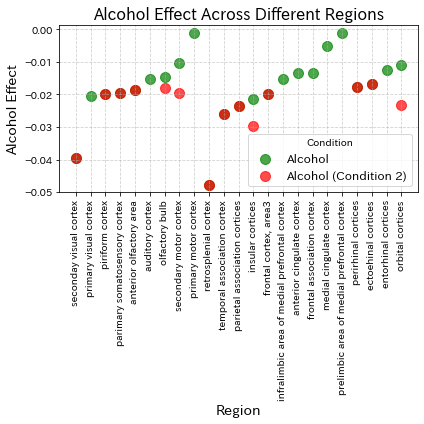

In [15]:
figure = plt.figure(figsize=(6, 6))
colors = ['green', 'red']
for i, x in enumerate(['alcohol', 'alcohol.2']):
    plt.scatter(alcohol_effect.category, alcohol_effect[x], 
                color=colors[i], 
                s=100,               # Increase marker size for better visibility
                alpha=0.7,          # Set transparency for better overlap visibility
                label='Alcohol' if i == 0 else 'Alcohol (Condition 2)')  # Label for legend
plt.xlabel('Region', fontsize=14)
plt.ylabel('Alcohol Effect', fontsize=14)
plt.xticks(rotation=90)
plt.title('Alcohol Effect Across Different Regions', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Condition', fontsize=12)
plt.tight_layout()  # Adjust layout to prevent clipping
plt.savefig('alcoholeffect.eps', format='eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


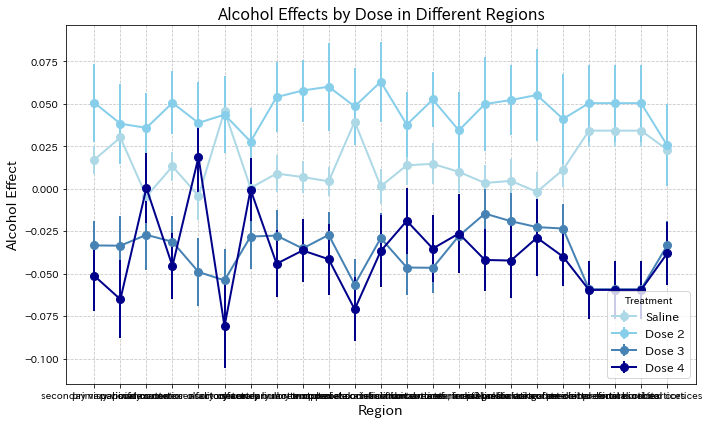

In [16]:
colors = ["#ADD8E6", "#87CEEB", "#4682B4", "#00008B"]
figure = plt.figure(figsize=(10,6))
for i, x in enumerate(['saline', 'dose1', 'dose2', 'dose3']):
    plt.errorbar(alcohol_effect.category, alcohol_effect[x], 
                 color=colors[i], 
                 yerr=alcohol_effect[x + '_sem'], 
                 label=f'Dose {i+1}' if i > 0 else 'Saline',
                 marker='o',            # Add markers
                 linestyle='-',        # Solid line
                 linewidth=2,          # Thicker line
                 markersize=8)         # Larger markers
plt.xlabel('Region', fontsize=14)
plt.ylabel('Alcohol Effect', fontsize=14)
plt.title('Alcohol Effects by Dose in Different Regions', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Treatment', fontsize=12)
plt.tight_layout()  # Adjust layout to prevent clipping
plt.savefig('originalvalues.eps', format='eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


ANOVA Results:
F-statistic: 150.62913263621712
p-value: 1.4998658390992242e-34


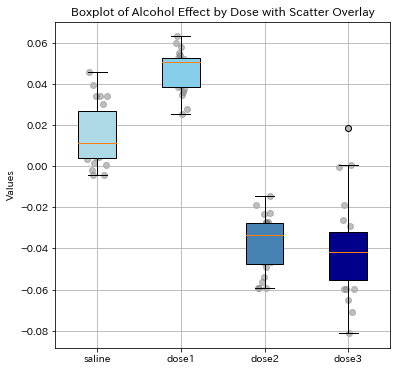

In [17]:
columns_to_plot = ['saline', 'dose1', 'dose2', 'dose3']
boxplot_colors = ["#ADD8E6", "#87CEEB", "#4682B4", "#00008B"]
plt.figure(figsize=(6, 6))
boxplot = plt.boxplot(
    [alcohol_effect[col] for col in columns_to_plot],
    labels=columns_to_plot,
    patch_artist=True
)
for patch, color in zip(boxplot['boxes'], boxplot_colors):
    patch.set_facecolor(color)
for i, col in enumerate(columns_to_plot):
    x = np.random.normal(i + 1, 0.05, size=len(alcohol_effect[col]))  # Add jitter to x position
    plt.scatter(x, alcohol_effect[col], alpha=0.5, color='gray')
plt.ylabel('Values')
plt.title('Boxplot of Alcohol Effect by Dose with Scatter Overlay')
plt.grid(True)
plt.savefig('originalvalue(motionregressedout).eps')
anova_result = stats.f_oneway(
    alcohol_effect['saline'],
    alcohol_effect['dose1'],
    alcohol_effect['dose2'],
    alcohol_effect['dose3']
)
print(f'ANOVA Results:\nF-statistic: {anova_result.statistic}\np-value: {anova_result.pvalue}')
plt.show()